# Project 1: Image registration

**Contents:** <br>

- [Goal](#goal)<br>
- [Deliverables](#deliverables)<br>
- [Assessment](#assessment)<br>

- [Preliminary guided project work](#guided_work)<br>

    A. [Getting started](#getting_started)<br>
    - [Dataset](#dataset)<br>
    - [Selecting corresponding point pairs](#selecting_point_pairs)<br>
        
  B. [Point-based registration](#point-based_reg)<br>
    - [Point-based affine image registration](#affine)<br>
    - [Evaluation of point-based affine image registration](#evaluation)<br>
        
  C. [Intensity-based registration](#intensity-based_reg)<br>
    - [Comparing the results of different registration methods](#comparison)<br>

- [Open-ended project work](#open-end)

<div id="goal"></div>

<div style="float:right;margin:-5px 5px"><img src="assets/read_ico.png" width="42" height="42"></div> 


## Goal
Develop Python code for point-based and intensity-based (medical) image registration. Propose and investigate a suitable research question of your choice. Use the developed code to perform image registration and evaluate and analyze the results.

The dataset you will be using in the first project originates from the [MRBrainS medical image analysis challenge](http://mrbrains13.isi.uu.nl/). It consists of 18 traverse slices of MR brain scans with two different sequences: T1-weighted and T2-FLAIR (3 patients $\times$ 3 slices per patient $\times$ 2 modalities). Please see the [Getting started](#getting_started) assignment below for more details on the dataset.

The assignment consists of two parts, as a first step there is preliminary guided project work, and as a second step you must investigate a suitable research question based on the methods you have developed. A research question based on the preliminary guided project work below, completing the programming tasks and answering the theory questions, is the minimal solution to this project. If this is done well and accompanied by a suitable report, this will be graded with a ‘sufficient’ grade. To achieve higher grades, you need to go beyond the minimal solution. You should use what you have implemented and the available data to come up with and answer a suitable research question. Write about this in your report.

<div id="deliverables"></div>

## Deliverables
A completed version of this notebook, the documented python code that you developed, and a report describing your research question, results and analysis. The report is expected in a short, concise format. It focusses on your specific research questions, results and discussion. The lecturers already know the background, the data and the general methodology. Your report therefore does not need to include an introduction on the clinical problem nor explanations of the background of image registration. You do have to include your design choices and motivation thereof.

Aim to present your most important findings in the main body of the report and (if needed) any additional information in an appendix. The following report structure is suggested for the main body of the report:

1. Introduce research question and hypothesis with its motivation (0.5 page)
2. Study design: which data did you use, what are the requirements of your method,
why did you make certain choices. Be as complete as possible w.r.t. the components
of a study design. (0.5 page)
3. Method, experiments and results for each research question (2 pages)
4. Discussion section with analysis of the results. (1 page)
5. Contributions: a brief description by each group member of their activities in the project which can be used to to adjust individual grades to reflect a student’s (lack of) contribution to the group
6. If you use large language models (such as ChatGPT) in your course work, you are required to declare how and for what they were used and to include a reflection on the use of such tools.

The page lengths above are indications. You are free to adapt them, with the constraint of a maximum length of five pages for the first four items listed.

The report must be submitted as a single PDF file. The documented code must be submitted as a single archive file (e.g. zip or 7z) that is self-contained and can be used to reproduce the results in the report. 

Note that there is no single correct solution for the project. You have to demonstrate to the reader that you understand the methods that you have studied and can critically analyze the results of applying the methods. Below, you can find a set of assignments (guided project work) that will help you get started with the project work and, when correctly completed, will present you with a **minimal solution**. Solutions which go beyond these assignments are of course encouraged. Additionally, include the solutions to the preliminary guided project work within this notebook in the archive file. 
<div id="assessment"></div>

## Assessment
The rubric that will be used for assessment of the project work is given in [this table](https://github.com/tueimage/8BE030-MIA/blob/master/rubric.md). Please check this carefully!

In [4]:
%load_ext autoreload
%autoreload 2

<div id='guided_work'></div>

## Preliminary guided project work

<div id="getting_started"></div>
<div style="float:right;margin:-5px 5px"><img src="assets/read_ico.png" width="42" height="42"></div> 

### A. Getting started
As an introduction, you will get familiar with the dataset that will be used in the first project and the control point selection tool that can be used to annotate corresponding points in pairs of related images. The annotated points can later be used to perform point-based registration and evaluation of the registration error.

<div id="dataset"></div>

### Dataset

The image dataset is located in the [image_data](https://github.com/tueimage/8BE030-MIA/tree/master/data/image_data) subfolder of the code for the registration exercises and project. The image filenames have the following format: `{Patient ID}_{Slice ID}_{Sequence}.tif`. For example, the filename `3_2_t1.tif` is the second slice from a T1-weighted scan of the third patient. Every T1 slice comes in two versions: original and transformed with some random transformation that can be identified with the `_d` suffix in the filename. This simulates a registration problem where you have to register two image acquisitions of the same patient (note however that some of the transformations that were used to simulate the second set of images are not realistic for brain imaging, e.g. brain scans typically do not encounter shearing between consecutive acquisitions).

<div style="float:right;margin:-5px 5px"><img src="assets/question_ico.png" width="42" height="42"></div> 

### *Question 1*:

With this dataset we can define two image registration problems: T1 to T1 registration (e.g. register `3_2_t1_d.tif` to `3_2_t1.tif`) and T2 to T1 registration (e.g. register `3_2_t2.tif` to `3_2_t1.tif`). Which one of these can be considered inter-modal image registration and which one intra-modal image registration?

<div id="selecting_point_pairs"></div>

### Selecting corresponding point pairs

A function called `cpselect` is provided to select control points in two different images. This function provides two numpy arrays of cartesian coordinates, one array for each image, of points selected in the two images. The coordinate format is a numpy array with the X and Y on row 0 and 1 respectively, and each column being a point.

Calling the function will cause a new interactive window to pop up, where you will see your two images and some instructions.
For convenience, the instructions can also be found below:

* First select a point in Image 1 and then its corresponding point in Image 2. This pattern should be repeated for as many control points as you need. If you do not follow this pattern, the output arrays will be incorrect.
* Left Mouse Button to create a point. 
* Right Mouse Button/Delete/Backspace to remove the newest point. 
* Middle Mouse Button/Enter to finish placing points. 

<div style="float:right;margin:-5px 5px"><img src="assets/todo_ico.png" width="42" height="42"></div> 

### *Task 1*:

Test the functionality of `cpselect` by running the following code example:

In [6]:
import sys
sys.path.append("../code")
import registration_util as util

I_path = '../data/image_data/1_1_t1.tif'
Im_path = '../data/image_data/1_1_t1_d.tif'

X, Xm = util.cpselect(I_path, Im_path)

print('X:\n{}'.format(X))
print('Xm:\n{}'.format(Xm))

KeyboardInterrupt: 

<div id="point-based_reg"></div>

## B. Point-based registration

<div style="float:right;margin:-5px 5px"><img src="assets/todo_ico.png" width="42" height="42"></div> 

<div id="affine"></div>

### Point-based affine image registration

From the provided dataset for this project, select one pair of T1 image slices (e.g. `3_2_t1.tif` and `3_2_t1_d.tif`) and use `my_cpselect` to select a set of corresponding points. Then, compute the affine transformation between the pair of images with `ls_affine` and apply it to the moving image using `image_transform`. 

Repeat the same for a pair of corresponding T1 and T2 slices (e.g. `3_2_t1.tif` and `3_2_t2.tif`).

In [12]:
import numpy as np
from registration import *

import matplotlib.pyplot as plt

def color_overlay(fixed_im, moving_im):
    fixed_norm = (fixed_im - fixed_im.min()) / (fixed_im.max() - fixed_im.min()) # Norm of fixed image
    moving_norm = (moving_im - moving_im.min()) / (moving_im.max() - moving_im.min()) # Norm of moving image
    
    overlay = np.zeros((fixed_im.shape[0], fixed_im.shape[1], 3))
    overlay[..., 0] = moving_norm  # Red
    overlay[..., 1] = fixed_norm   # Green
    overlay[..., 2] = moving_norm  # Blue
    
    return overlay

### Intra-modal registration

In [8]:
# We first select the images and points we want to target
image_f = '../data/image_data/3_2_t1.tif'
image_d = '../data/image_data/3_2_t1_d.tif'
X, Xm = util.cpselect(image_f, image_d)


In [9]:
# We compute the affine transformation
T = ls_affine(X, Xm)
print('Estimated Transformation Matrix:\n', T)

Estimated Transformation Matrix:
 [[ 9.23159684e-01 -1.24460697e-02 -4.01886434e-01]
 [ 4.99117277e-03  9.96000073e-01 -1.15628136e+01]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]


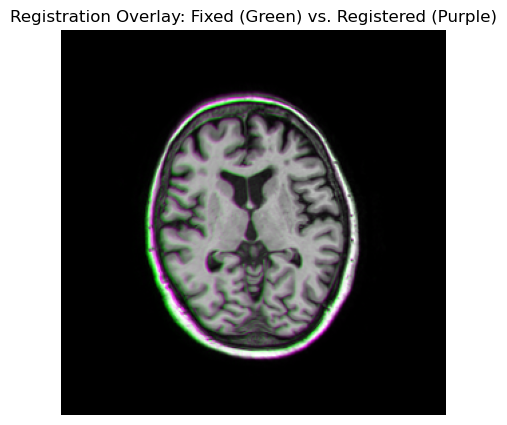

In [15]:
img_f = plt.imread(image_f)
img_d = plt.imread(image_d)
T_inv = np.linalg.inv(T) # We apply the inverse of T because affine_transform maps output to input
registered_img, registered_coords = image_transform(img_d, T_inv)
overlay_img = color_overlay(img_f, registered_img)

plt.figure(figsize=(5, 5))
plt.imshow(overlay_img)
plt.title('Registration Overlay: Fixed (Green) vs. Registered (Purple)')
plt.axis('off')
plt.show()

### Inter-modal Registration

In [16]:
# We first select the images and points we want to target
image_f = '../data/image_data/3_2_t1.tif'
image_d = '../data/image_data/3_2_t2.tif'
X, Xm = util.cpselect(image_f, image_d)


In [17]:
# We compute the affine transformation
T = ls_affine(X, Xm)
print('Estimated Transformation Matrix:\n', T)

Estimated Transformation Matrix:
 [[ 0.93908279 -0.02659641  0.6519018 ]
 [-0.02205968  1.00888532  3.41049702]
 [ 0.          0.          1.        ]]


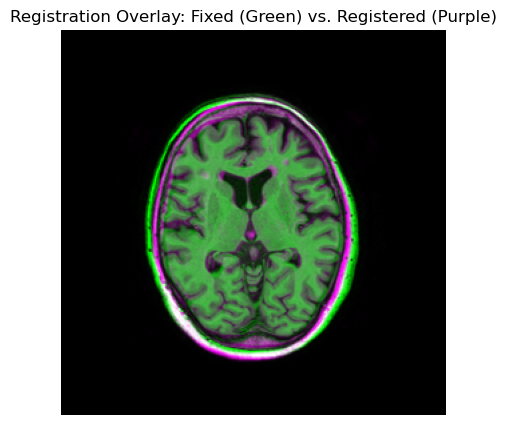

In [18]:
img_f = plt.imread(image_f)
img_d = plt.imread(image_d)
T_inv = np.linalg.inv(T) # We apply the inverse of T because affine_transform maps output to input
registered_img, registered_coords = image_transform(img_d, T_inv)
overlay_img = color_overlay(img_f, registered_img)

plt.figure(figsize=(5, 5))
plt.imshow(overlay_img)
plt.title('Registration Overlay: Fixed (Green) vs. Registered (Purple)')
plt.axis('off')
plt.show()

<div id="evaluation"></div>

### Evaluation of point-based affine image registration

<div style="float:right;margin:-5px 5px"><img src="assets/question_ico.png" width="42" height="42"></div> 

### *Question 2*:
Describe how you would estimate the registration error. (Hint: Should you use the same points that you used for computing the affine transformation to also compute the registration error?) How does the number of corresponding point pairs affect the registration error? Motivate all your answers.

<div id="intensity-based_reg"></div>

## C. Intensity-based registration

<div style="float:right;margin:-5px 5px"><img src="assets/todo_ico.png" width="42" height="42"></div> 

<div id="comparison"></div>

### Comparing the results of different registration methods

The following Python script (provided as `intensity_based_registration_demo()`) performs rigid intensity-based registration of two images using the normalized-cross correlation as a similarity metric:

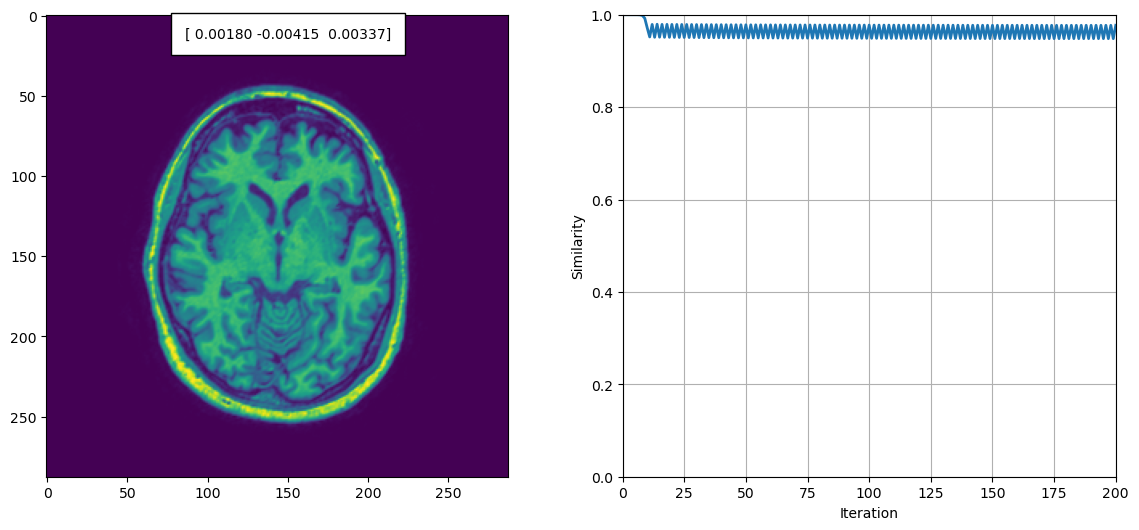

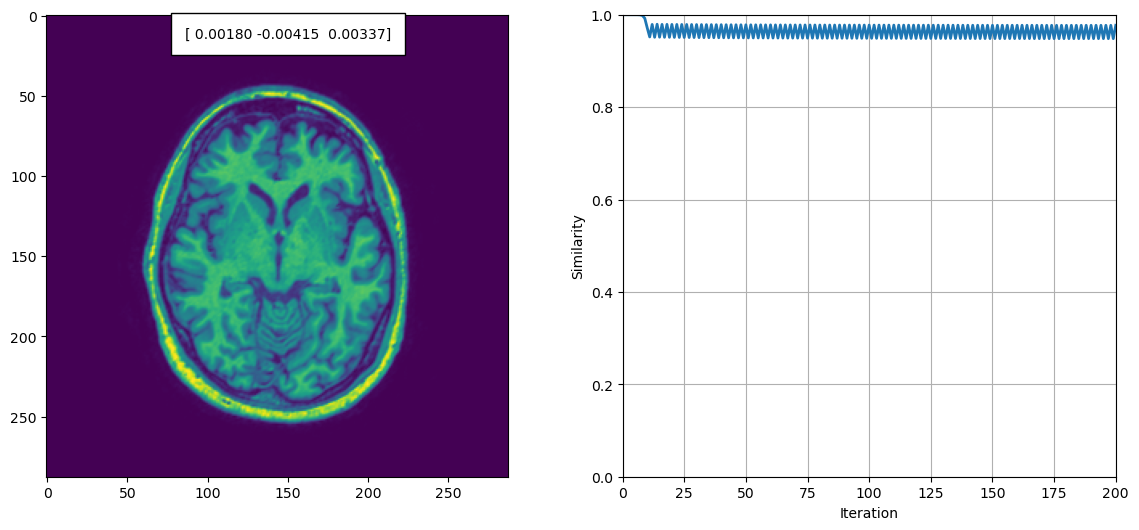

In [19]:
%matplotlib inline
import sys
sys.path.append("../code")
from registration_project import intensity_based_registration_demo

intensity_based_registration_demo()

### <div style="float:right;margin:-5px 5px"><img src="assets/todo_ico.png" width="35" height="35"></div>  *Task 2*:

By changing the similarity function and the initial parameter vector, you can also use this script to perform affine registration and use mutual information as a similarity measure. Do not forget to also change the transformation for the visualization of the results.

Using the provided dataset and the functions that you have implemented in the exercises, perform the following series of experiments:

1. Rigid intensity-based registration of two T1 slices (e.g. `1_1_t1.tif` and `1_1_t1_d.tif`) using normalized cross-correlation as a similarity measure.
2. Affine intensity-based registration of two T1 slices (e.g. `1_1_t1.tif` and `1_1_t1_d.tif`) using normalized cross-correlation as a similarity measure.
3. Affine intensity-based registration of a T1 and a T2 slice (e.g. `1_1_t1.tif` and `1_1_t2.tif`) using normalized cross-correlation as a similarity measure.
4. Affine intensity-based registration of two T1 slices (e.g. `1_1_t1.tif` and `1_1_t1_d.tif`) using mutual information as a similarity measure.
5. Affine intensity-based registration of a T1 slice and a T2 slice (e.g. `1_1_t1.tif` and `1_1_t2.tif`) using mutual information as a similarity measure.

Compare the results from each experiment. If a method fails, describe why you think it fails. Note that you will most likely have to try different values for the learning rate in each experiment in order to find the one that works best. 

#### 1. Rigid intensity-based registration of two T1 slices using normalized cross-correlation as a similarity measure.

In [25]:
image_f = plt.imread('../data/image_data/3_2_t1.tif')
image_d = plt.imread('../data/image_data/3_2_t1_d.tif')

x = np.array([0.0, 0.0, 0.0]) # We initialize the parameters

fun = lambda x: rigid_corr(image_f, image_d, x, return_transform=False)

# Optimization hyperparameters
lr = 0.001      
num_iter = 200 

similarity_vals = []
for k in range(num_iter):
    g = ngradient(fun, x) # central difference formula
    
    x += g*lr #x_new = x_old + gradient*learning_rate


    current_sim = fun(x)
    similarity_vals.append(current_sim)

# Final results
C, Im_registered, Th_final = rigid_corr(image_f, image_d, x, return_transform=True)

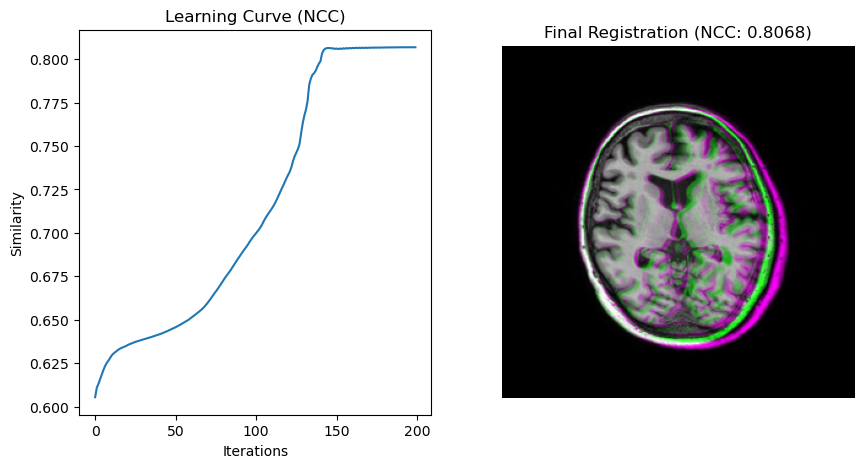

In [26]:
overlay = color_overlay(image_f, Im_registered)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(similarity_vals)
plt.title('Learning Curve (NCC)')
plt.xlabel('Iterations')
plt.ylabel('Similarity')

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title(f'Final Registration (NCC: {C:.4f})')
plt.axis('off')
plt.show()

#### 2. Affine intensity-based registration of two T1 slices using normalized cross-correlation as a similarity measure.

In [30]:
image_f = plt.imread('../data/image_data/3_2_t1.tif')
image_d = plt.imread('../data/image_data/3_2_t1_d.tif')

x = np.array([0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0]) # We initialize the parameters

fun = lambda x: affine_corr(image_f, image_d, x, return_transform=False)

# Optimization hyperparameters
lr = 0.001      
num_iter = 200 

similarity_vals = []
for k in range(num_iter):
    g = ngradient(fun, x) # central difference formula
    
    x += g*lr #x_new = x_old + gradient*learning_rate


    current_sim = fun(x)
    similarity_vals.append(current_sim)

# Final results
C, Im_registered, Th_final = affine_corr(image_f, image_d, x, return_transform=True)

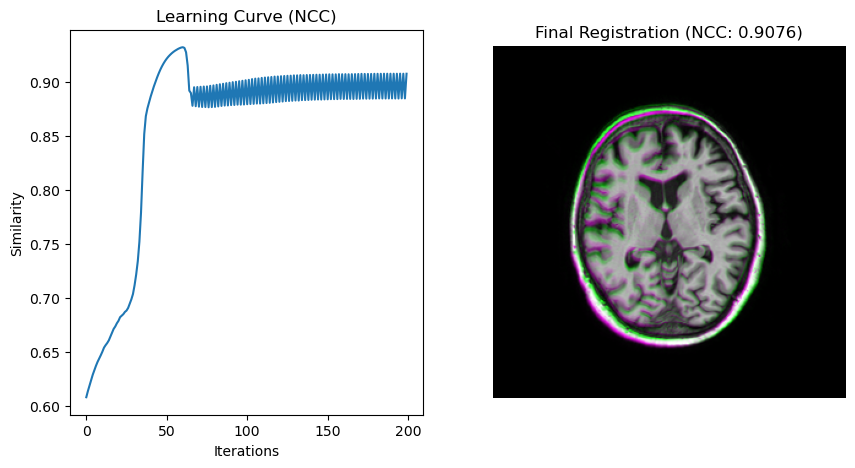

In [31]:
overlay = color_overlay(image_f, Im_registered)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(similarity_vals)
plt.title('Learning Curve (NCC)')
plt.xlabel('Iterations')
plt.ylabel('Similarity')

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title(f'Final Registration (NCC: {C:.4f})')
plt.axis('off')
plt.show()

#### 3. Affine intensity-based registration of a T1 and a T2 slice using normalized cross-correlation as a similarity measure.

In [33]:
image_f = plt.imread('../data/image_data/3_2_t1.tif')
image_d = plt.imread('../data/image_data/3_2_t2.tif')

x = np.array([0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0]) # We initialize the parameters

fun = lambda x: affine_corr(image_f, image_d, x, return_transform=False)


# Optimization hyperparameters
lr = 0.001      
num_iter = 200 

similarity_vals = []
for k in range(num_iter):
    g = ngradient(fun, x) # central difference formula
    
    x += g*lr #x_new = x_old + gradient*learning_rate


    current_sim = fun(x)
    similarity_vals.append(current_sim)

# Final results
C, Im_registered, Th_final = affine_corr(image_f, image_d, x, return_transform=True)

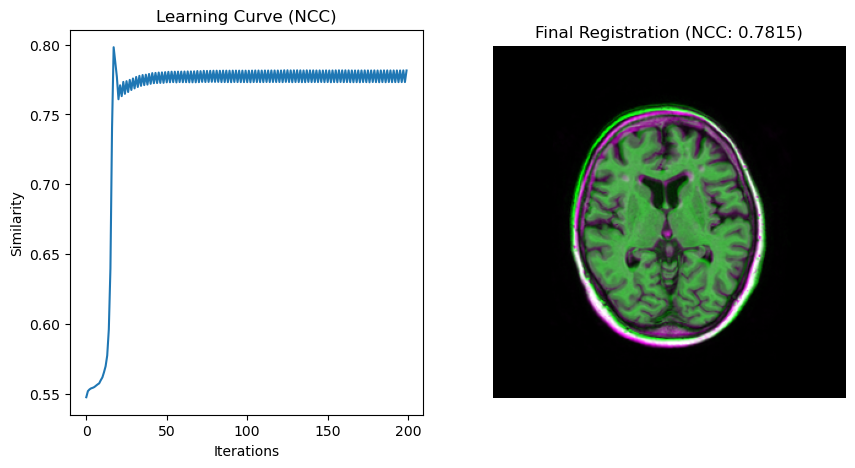

In [34]:
overlay = color_overlay(image_f, Im_registered)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(similarity_vals)
plt.title('Learning Curve (NCC)')
plt.xlabel('Iterations')
plt.ylabel('Similarity')

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title(f'Final Registration (NCC: {C:.4f})')
plt.axis('off')
plt.show()

#### 4. Affine intensity-based registration of two T1 slices using mutual information as a similarity measure.


In [39]:
image_f = plt.imread('../data/image_data/3_2_t1.tif')
image_d = plt.imread('../data/image_data/3_2_t1_d.tif')

x = np.array([0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0]) # We initialize the parameters

fun = lambda x: affine_mi(image_f, image_d, x, return_transform=False)


# Optimization hyperparameters
lr = 0.001      
num_iter = 100 

similarity_vals = []
for k in range(num_iter):
    g = ngradient(fun, x) # central difference formula
    
    x += g*lr #x_new = x_old + gradient*learning_rate


    current_sim = fun(x)
    similarity_vals.append(current_sim)

# Final results
C, Im_registered, Th_final = affine_mi(image_f, image_d, x, return_transform=True)

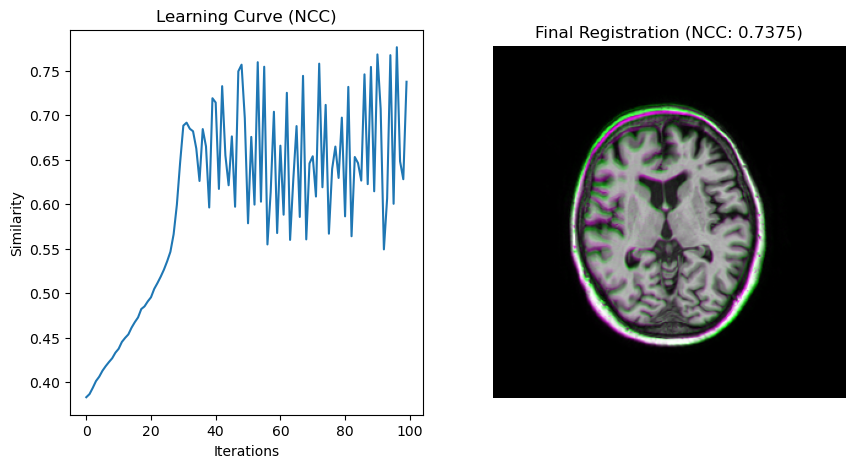

In [ ]:
overlay = color_overlay(image_f, Im_registered)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(similarity_vals)
plt.title('Learning Curve (nats)')
plt.xlabel('Iterations')
plt.ylabel('Similarity')

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title(f'Final Registration (nats: {C:.4f})')
plt.axis('off')
plt.show()

#### 5. Affine intensity-based registration of a T1 slice and a T2 slice using mutual information as a similarity measure.

In [41]:
image_f = plt.imread('../data/image_data/3_2_t1.tif')
image_d = plt.imread('../data/image_data/3_2_t2.tif')

x = np.array([0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0]) # We initialize the parameters

fun = lambda x: affine_mi(image_f, image_d, x, return_transform=False)


# Optimization hyperparameters
lr = 0.001      
num_iter = 100 

similarity_vals = []
for k in range(num_iter):
    g = ngradient(fun, x) # central difference formula
    
    x += g*lr #x_new = x_old + gradient*learning_rate


    current_sim = fun(x)
    similarity_vals.append(current_sim)

# Final results
C, Im_registered, Th_final = affine_mi(image_f, image_d, x, return_transform=True)

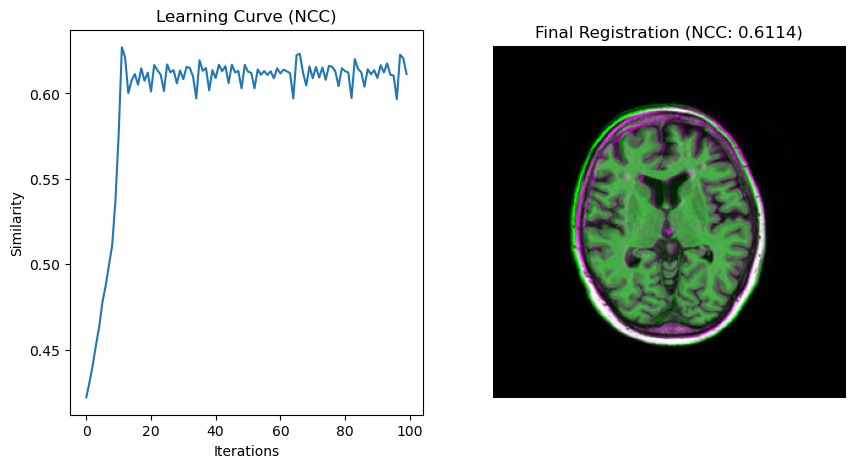

In [ ]:
overlay = color_overlay(image_f, Im_registered)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(similarity_vals)
plt.title('Learning Curve (nats)')
plt.xlabel('Iterations')
plt.ylabel('Similarity')

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title(f'Final Registration (nats: {C:.4f})')
plt.axis('off')
plt.show()

<div id="open-end"></div>

<div style="float:right;margin:-5px 5px"><img src="assets/todo_ico.png" width="42" height="42"></div> 


## Open-ended project work

Define and motivate one research question that you will investigate. This can be a question relating to a method (e.g. what is the impact of X on a particular method) or relating to the problem (e.g. does a specific method fail in specific cases). 
It is recommended to get feedback on your research question from the teaching assistants.

### Multi-resolution (pyramid) registration

In [41]:
import sys
sys.path.append("../code")
import registration_util as util
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter, zoom
import registration as reg
import warnings
import time

def multi_resolution_registration(I_full, Im_full, method='mi', levels=[0.25, 0.5, 1.0], num_iter=[100,50,10], lr=[0.008, 0.004, 0.001], tolerance=1e-4):
    """
    Performs multi-resolution affine registration.
    
    levels: list of scaling factors (e.g., [0.25, 0.5, 1.0])
    method: 'mi' for Mutual Information or 'corr' for Correlation
    """

    # [phi, sx, sy, shx, shy, tx, ty]
    x = np.array([0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0])

    # We store how many iterations each level took
    iterations_per_level = []

    # Select the objective function based on the experiment
    if method == 'mi':
        reg_func = reg.affine_mi
    else:
        reg_func = reg.affine_corr

    current_scale = levels[0]

    for i, scale in enumerate(levels):
        # We calculate sigma based on the scale to avoid aliasing.
        sigma = (1.0/scale) - 1.0 if scale < 1.0 else 0

        I_blurred = gaussian_filter(I_full, sigma=sigma)
        Im_blurred = gaussian_filter(Im_full, sigma=sigma)

        # we downsample images for the current level
        I_low = zoom(I_blurred, scale)
        Im_low = zoom(Im_blurred, scale)

        # we adjust translation parameters to take into account the new scale
        if i > 0:
            scale_factor = scale / current_scale
            x[5]*=scale_factor # Update tx
            x[6]*=scale_factor # Update ty
        
        # we extract the specific hyperparameter for THIS specific level
        current_num_iter = num_iter[i] 
        current_lr = lr[i]
        current_scale = scale
        
        # we define the local objective function for this level
        fun = lambda x_iter: reg_func(I_low, Im_low, x_iter, return_transform=False)
        
        count=0
        prev_sim = -np.inf
        # we optimizie for the current level using the level-specific limit
        for k in range(current_num_iter):
            count=k+1
            # we compute gradient using your numerical differentiation
            g = reg.ngradient(fun, x)
            
            # we update parameters using the level-specific learning rate
            x += g*current_lr

            # early stopping if needed
            current_sim = fun(x)
            if abs(current_sim - prev_sim) < tolerance:
                break
            prev_sim = current_sim
        iterations_per_level.append(count)

    # we compute the final registration using full resolution and final parameters
    sim_final, Im_reg, _ = reg_func(I_full, Im_full, x, return_transform=True)
    
    return x, sim_final, Im_reg, iterations_per_level

In [ ]:
"""
# define the search space for the multi-resolution registration

schedules = [
    {
        "name": "3-Lvl: Baseline (flat)", 
        "levels": [0.25, 0.5, 1.0], 
        "iter": [50, 50, 50], 
        "lr": [0.002, 0.002, 0.002]
    },
    {
        "name": "3-Lvl: Aggressive bottom", 
        "levels": [0.25, 0.5, 1.0], 
        "iter": [150, 50, 10], 
        "lr": [0.008, 0.004, 0.001]
    },
    {
        "name": "3-Lvl: Moderate taper", 
        "levels": [0.25, 0.5, 1.0], 
        "iter": [100, 50, 20], 
        "lr": [0.004, 0.002, 0.001]
    },
    {
        "name": "3-Lvl: Fast cautious", 
        "levels": [0.25, 0.5, 1.0], 
        "iter": [100, 30, 10], 
        "lr": [0.002, 0.001, 0.001]
    },
    {
        "name": "3-Lvl: Ultra deep bottom", 
        "levels": [0.25, 0.5, 1.0], 
        "iter": [200, 20, 5], 
        "lr": [0.01, 0.002, 0.0005]
    },

    {
        "name": "4-Lvl: Deep start taper", 
        "levels": [0.125, 0.25, 0.5, 1.0], 
        "iter": [200, 100, 30, 10], 
        "lr": [0.01, 0.005, 0.002, 0.001]
    },
    {
        "name": "4-Lvl: Deep start fast", 
        "levels": [0.125, 0.25, 0.5, 1.0], 
        "iter": [150, 50, 20, 5], 
        "lr": [0.01, 0.004, 0.002, 0.001]
    },

    {
        "name": "2-Lvl: Half-to-Full (Skip 0.25)", 
        "levels": [0.5, 1.0], 
        "iter": [50, 20], 
        "lr": [0.004, 0.001]
    },
    {
        "name": "2-Lvl: Quarter-to-Full (Skip 0.5)", 
        "levels": [0.25, 1.0], 
        "iter": [100, 20], 
        "lr": [0.005, 0.001]
    },

    {
        "name": "4-Lvl: Smooth Gradient", 
        "levels": [0.25, 0.5, 0.75, 1.0], 
        "iter": [100, 50, 30, 10], 
        "lr": [0.005, 0.003, 0.002, 0.001]
    }
]

# Arrays to store results
results_t1 = []
results_t2 = []
"""

In [60]:
# run this to compute the values for the best schedules for T1-T1 and T1-T2

schedules = [
    {
        "name": "3-Lvl: Fast cautious", 
        "levels": [0.25, 0.5, 1.0], 
        "iter": [100, 30, 10], 
        "lr": [0.002, 0.001, 0.001]
    },
    {
        "name": "3-Lvl: Ultra deep bottom", 
        "levels": [0.25, 0.5, 1.0], 
        "iter": [200, 20, 5], 
        "lr": [0.01, 0.002, 0.0005]
    }
]

# Arrays to store results
results_t1 = []
results_t2 = []

In [ ]:
# execute the targeted grid search

print("Starting parameter optimization search...\n")

for sched_idx, sched in enumerate(schedules):
    print(f"Testing Schedule {sched_idx + 1}/{len(schedules)}: {sched['name']}")
    
    sims_t1_temp, iters_t1_temp, times_t1_temp = [], [], []
    sims_t2_temp, iters_t2_temp, times_t2_temp = [], [], []
    
    # Catch mathematical warnings (like overflows from bad learning rates)
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        
        for i in range(3):
            for j in range(3):
                image_f = plt.imread(f'../data/image_data/{i+1}_{j+1}_t1.tif')
                image_d = plt.imread(f'../data/image_data/{i+1}_{j+1}_t1_d.tif')
                image_d_t2 = plt.imread(f'../data/image_data/{i+1}_{j+1}_t2.tif')

                # Run Intra-Modal (T1-T1)
                t0_t1 = time.perf_counter()
                _, sim_t1, _, it_t1 = multi_resolution_registration(
                    image_f, image_d, method='mi', levels=sched['levels'], 
                    num_iter=sched['iter'], lr=sched['lr']
                )
                t1_t1 = time.perf_counter()
                times_t1_temp.append(t1_t1 - t0_t1)
                
                # Run Inter-Modal (T1-T2)
                t0_t2 = time.perf_counter()
                _, sim_t2, _, it_t2 = multi_resolution_registration(
                    image_f, image_d_t2, method='mi', levels=sched['levels'], 
                    num_iter=sched['iter'], lr=sched['lr']
                )
                t1_t2 = time.perf_counter()
                times_t2_temp.append(t1_t2 - t0_t2)

                sims_t1_temp.append(sim_t1)
                sims_t2_temp.append(sim_t2)
                iters_t1_temp.append(it_t1)
                iters_t2_temp.append(it_t2)
        
        # Check if this schedule caused instability
        if len(w) > 0:
            print(f"  -> WARNING: Schedule {sched['name']} caused {len(w)} numeric warnings (likely gradient overflow).")
            # You might choose to penalize or skip this result entirely
            
    # Calculate FRE (Full-Resolution Equivalents) for this schedule
    weights = np.array(sched['levels'])**2
    
    # T1 FRE
    iters_t1_array = np.array(iters_t1_temp)
        
    # T2 FRE
    iters_t2_array = np.array(iters_t2_temp)

    # Calculate averages
    mean_sim_t1, mean_fre_t1, mean_time_t1 = np.mean(sims_t1_temp), np.mean(np.sum(iters_t1_array * weights, axis=1)), np.mean(times_t1_temp)
    mean_sim_t2, mean_fre_t2, mean_time_t2 = np.mean(sims_t2_temp), np.mean(np.sum(iters_t2_array * weights, axis=1)), np.mean(times_t2_temp)

    std_sim_t1, std_fre_t1, std_time_t1 = np.std(sims_t1_temp), np.std(np.sum(iters_t1_array * weights, axis=1)), np.std(times_t1_temp)
    std_sim_t2, std_fre_t2, std_time_t2 = np.std(sims_t2_temp), np.std(np.sum(iters_t2_array * weights, axis=1)), np.std(times_t2_temp)

    results_t1.append({"name": sched['name'], "mi": mean_sim_t1, "fre": mean_fre_t1})
    results_t2.append({"name": sched['name'], "mi": mean_sim_t2, "fre": mean_fre_t2})

    print(f"  -> T1-T1: MI={mean_sim_t1:.4f} ± {std_sim_t1:.4f}, FRE={mean_fre_t1:.2f} ± {std_fre_t1:.2f}, Time={mean_time_t1:.3f}s ± {std_time_t1:.3f}s")
    print(f"  -> T1-T2: MI={mean_sim_t2:.4f} ± {std_sim_t2:.4f}, FRE={mean_fre_t2:.2f} ± {std_fre_t2:.2f}, Time={mean_time_t2:.3f}s ± {std_time_t2:.3f}s\n")

Starting parameter optimization search...

Testing Schedule 1/2: 3-Lvl: Fast cautious


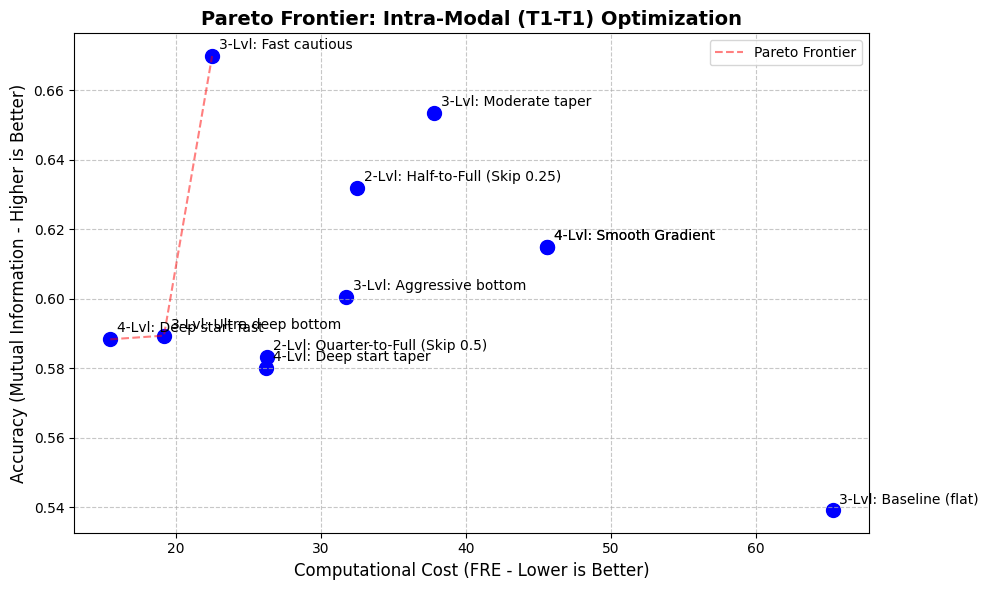

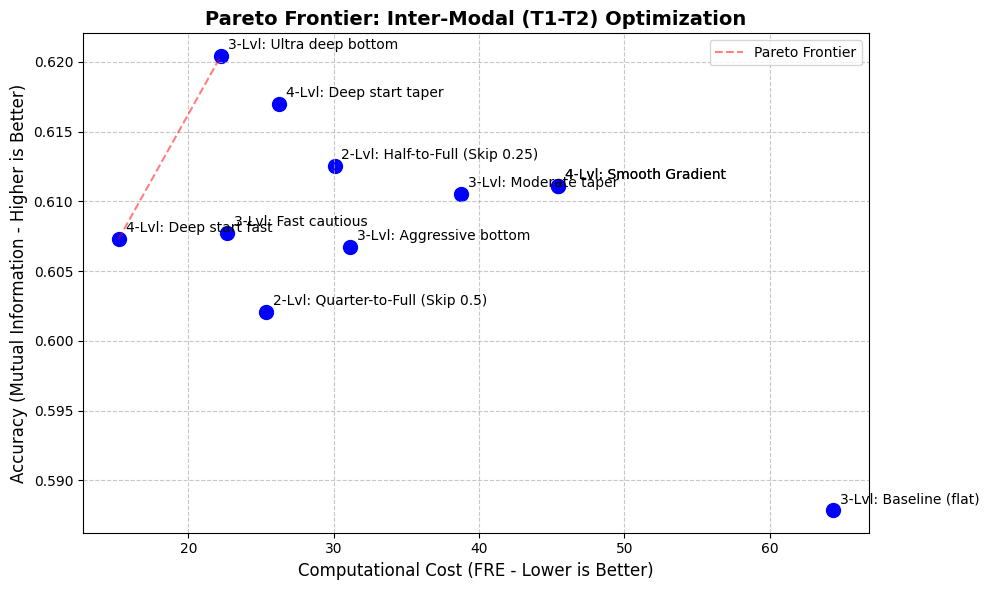

In [45]:
# plot the performance graphs

def plot_pareto(results, title):
    # Extract data
    names = [r["name"] for r in results]
    mis = [r["mi"] for r in results]
    fres = [r["fre"] for r in results]
    
    plt.figure(figsize=(10, 6))
    
    # Note: For MI, higher is better. For FRE, lower is better.
    # Therefore, the "best" points are in the top-left of the graph.
    plt.scatter(fres, mis, color='blue', s=100)
    
    # Annotate points
    for i, name in enumerate(names):
        plt.annotate(name, (fres[i], mis[i]), xytext=(5, 5), textcoords='offset points')
        
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Computational Cost (FRE - Lower is Better)', fontsize=12)
    plt.ylabel('Accuracy (Mutual Information - Higher is Better)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Draw a mock Pareto front line (conceptual visualization)
    # Sort by FRE ascending to draw the line
    sorted_indices = np.argsort(fres)
    fres_sorted = np.array(fres)[sorted_indices]
    mis_sorted = np.array(mis)[sorted_indices]
    
    pareto_fres = [fres_sorted[0]]
    pareto_mis = [mis_sorted[0]]
    current_max_mi = mis_sorted[0]
    
    for i in range(1, len(fres_sorted)):
        if mis_sorted[i] > current_max_mi:
            pareto_fres.append(fres_sorted[i])
            pareto_mis.append(mis_sorted[i])
            current_max_mi = mis_sorted[i]
            
    plt.plot(pareto_fres, pareto_mis, 'r--', alpha=0.5, label="Pareto Frontier")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Generate the two plots
plot_pareto(results_t1, "Pareto Frontier: Intra-Modal (T1-T1) Optimization")
plot_pareto(results_t2, "Pareto Frontier: Inter-Modal (T1-T2) Optimization")

### Run an example with the winning pyramid hyperparameters

In [46]:
# Function to create an RGB overlay for visualization (Fixed=Red, Moving=Green)
def create_overlay(I_fixed, I_moving):
    # Normalize images between 0 and 1
    f_norm = (I_fixed - np.min(I_fixed)) / (np.max(I_fixed) - np.min(I_fixed))
    m_norm = (I_moving - np.min(I_moving)) / (np.max(I_moving) - np.min(I_moving))
    
    # Stack into an RGB array
    return np.stack([f_norm, m_norm, np.zeros_like(f_norm)], axis=-1)

In [47]:
# 1. LOAD ONE EXAMPLE PAIR
i, j = 2, 1
image_f = plt.imread(f'../data/image_data/{i+1}_{j+1}_t1.tif')
image_d_t1 = plt.imread(f'../data/image_data/{i+1}_{j+1}_t1_d.tif')
image_d_t2 = plt.imread(f'../data/image_data/{i+1}_{j+1}_t2.tif')

In [48]:
# 2. DEFINE THE OPTIMAL SCHEDULES
sched_t1 = {
    "name": "T1-T1", 
    "levels": [0.25, 0.5, 1.0], 
    "iter": [100, 30, 10], 
    "lr": [0.002, 0.001, 0.001]
}

sched_t2 = {
    "name": "T1-T2", 
    "levels": [0.25, 0.5, 1.0], 
    "iter": [200, 20, 5], 
    "lr": [0.01, 0.002, 0.0005]
}

In [49]:
# 3. EXECUTE REGISTRATIONS
print(f"Executing {sched_t1['name']}...")
print(f"Executing {sched_t2['name']}...")

with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")

    # Run T1-T1 Registration
    _, sim_t1, reg_t1, _ = multi_resolution_registration(
        image_f, image_d_t1, method='mi', 
        levels=sched_t1['levels'], num_iter=sched_t1['iter'], 
        lr=sched_t1['lr'], tolerance=1e-3
    )

    # Run T1-T2 Registration
    _, sim_t2, reg_t2, _ = multi_resolution_registration(
        image_f, image_d_t2, method='mi', 
        levels=sched_t2['levels'], num_iter=sched_t2['iter'], 
        lr=sched_t2['lr'], tolerance=1e-3
    )
    
    if len(w) > 0:
        print(f"WARNING: Registered {len(w)} numeric warnings during execution.")

Executing T1-T1...
Executing T1-T2...


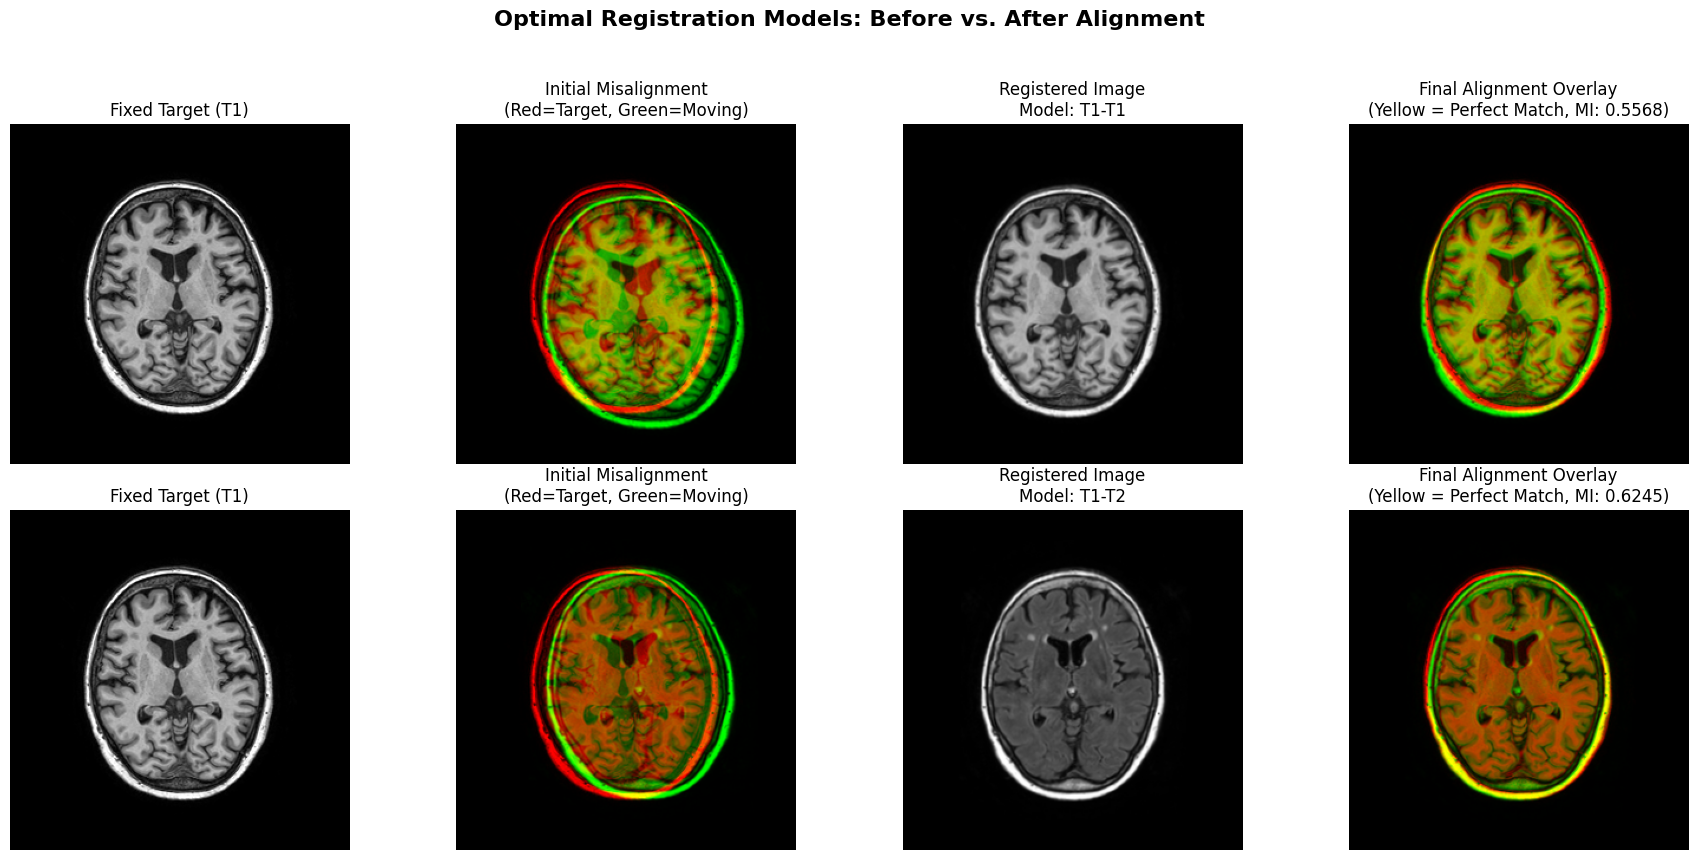

In [50]:
# 4. PLOT THE RESULTS
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Optimal Registration Models: Before vs. After Alignment", fontsize=16, fontweight='bold')

# ROW 1: T1-T1
axes[0, 0].imshow(image_f, cmap='gray')
axes[0, 0].set_title("Fixed Target (T1)")
axes[0, 0].axis('off')

axes[0, 1].imshow(create_overlay(image_f, image_d_t1))
axes[0, 1].set_title("Initial Misalignment\n(Red=Target, Green=Moving)")
axes[0, 1].axis('off')

axes[0, 2].imshow(reg_t1, cmap='gray')
axes[0, 2].set_title(f"Registered Image\nModel: {sched_t1['name']}")
axes[0, 2].axis('off')

axes[0, 3].imshow(create_overlay(image_f, reg_t1))
axes[0, 3].set_title(f"Final Alignment Overlay\n(Yellow = Perfect Match, MI: {sim_t1:.4f})")
axes[0, 3].axis('off')

# ROW 2: T1-T2
axes[1, 0].imshow(image_f, cmap='gray')
axes[1, 0].set_title("Fixed Target (T1)")
axes[1, 0].axis('off')

axes[1, 1].imshow(create_overlay(image_f, image_d_t2))
axes[1, 1].set_title("Initial Misalignment\n(Red=Target, Green=Moving)")
axes[1, 1].axis('off')

axes[1, 2].imshow(reg_t2, cmap='gray')
axes[1, 2].set_title(f"Registered Image\nModel: {sched_t2['name']}")
axes[1, 2].axis('off')

axes[1, 3].imshow(create_overlay(image_f, reg_t2))
axes[1, 3].set_title(f"Final Alignment Overlay\n(Yellow = Perfect Match, MI: {sim_t2:.4f})")
axes[1, 3].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## PAT + pyramid

In [51]:
import PAT_util as pat

def multi_resolution_registration_pat(I_full, Im_full, method='mi', 
                                      levels=[0.25, 0.5, 1.0], 
                                      num_iter=[50, 20, 10],   
                                      lr=[0.005, 0.002, 0.001], 
                                      tolerance=1e-3):
    
    # 1. Run PAT to get the initial rigid alignment matrix (Th)
    Th_pat = pat.principal_axes_transform(I_full, Im_full)
    
    # 2. Extract rotation angle (phi) and translations (tx, ty) from the 3x3 matrix
    phi = np.arctan2(Th_pat[1, 0], Th_pat[0, 0])
    tx_full = Th_pat[0, 2]
    ty_full = Th_pat[1, 2]
    
    # 3. Initialize the affine parameter array: [phi, sx, sy, shx, shy, tx, ty]
    # CRITICAL: Scale the full-resolution translations to match the starting level
    start_scale = levels[0]
    x = np.array([phi, 1.0, 1.0, 0.0, 0.0, tx_full * start_scale, ty_full * start_scale])

    iterations_per_level = []

    # Select the objective function based on the experiment
    if method == 'mi':
        reg_func = reg.affine_mi
    else:
        reg_func = reg.affine_corr

    current_scale = levels[0]

    for i, scale in enumerate(levels):
        # We calculate sigma based on the scale to avoid aliasing.
        sigma = (1.0/scale) - 1.0 if scale < 1.0 else 0

        I_blurred = gaussian_filter(I_full, sigma=sigma)
        Im_blurred = gaussian_filter(Im_full, sigma=sigma)

        # we downsample images for the current level
        I_low = zoom(I_blurred, scale)
        Im_low = zoom(Im_blurred, scale)

        # we adjust translation parameters to take into account the new scale
        if i > 0:
            scale_factor = scale / current_scale
            x[5]*=scale_factor # Update tx
            x[6]*=scale_factor # Update ty
        
        # we extract the specific hyperparameter for THIS specific level
        current_num_iter = num_iter[i] 
        current_lr = lr[i]
        current_scale = scale
        
        # we define the local objective function for this level
        fun = lambda x_iter: reg_func(I_low, Im_low, x_iter, return_transform=False)
        
        count=0
        prev_sim = -np.inf
        # we optimizie for the current level using the level-specific limit
        for k in range(current_num_iter):
            count=k+1
            # we compute gradient using your numerical differentiation
            g = reg.ngradient(fun, x)
            
            # we update parameters using the level-specific learning rate
            x += g*current_lr

            # early stopping if needed
            current_sim = fun(x)
            if abs(current_sim - prev_sim) < tolerance:
                break
            prev_sim = current_sim
        iterations_per_level.append(count)

    # we compute the final registration using full resolution and final parameters
    sim_final, Im_reg, _ = reg_func(I_full, Im_full, x, return_transform=True)
    
    return x, sim_final, Im_reg, iterations_per_level

In [52]:
schedules_pat = [
    {
        "name": "PAT + Light Taper", 
        "levels": [0.25, 0.5, 1.0], 
        "iter": [30, 20, 10], 
        "lr": [0.005, 0.002, 0.001]
    },
    {
        "name": "PAT + Micro Finetune", 
        "levels": [0.25, 0.5, 1.0], 
        "iter": [15, 10, 5], 
        "lr": [0.008, 0.002, 0.001]
    }
]

In [54]:
print("Starting full dataset PAT + pyramid evaluation...\n")

for sched_idx, sched in enumerate(schedules_pat):
    print(f"Testing Schedule: {sched['name']}")
    
    sims_t1_temp, iters_t1_temp, times_t1_temp = [], [], []
    sims_t2_temp, iters_t2_temp, times_t2_temp = [], [], []
    
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        
        # Loop through all 3 patients and all 3 slices (9 pairs total)
        for i in range(3):
            for j in range(3):
                image_f = plt.imread(f'../data/image_data/{i+1}_{j+1}_t1.tif')
                image_d_t1 = plt.imread(f'../data/image_data/{i+1}_{j+1}_t1_d.tif')
                image_d_t2 = plt.imread(f'../data/image_data/{i+1}_{j+1}_t2.tif')

                # Run Intra-Modal (T1-T1)
                t0_t1 = time.perf_counter()
                _, sim_t1, _, it_t1 = multi_resolution_registration_pat(
                    image_f, image_d_t1, method='mi', 
                    levels=sched['levels'], num_iter=sched['iter'], 
                    lr=sched['lr'], tolerance=1e-3
                )
                t1_t1 = time.perf_counter()
                times_t1_temp.append(t1_t1 - t0_t1)
                
                # Run Inter-Modal (T1-T2)
                t0_t2 = time.perf_counter()
                _, sim_t2, _, it_t2 = multi_resolution_registration_pat(
                    image_f, image_d_t2, method='mi', 
                    levels=sched['levels'], num_iter=sched['iter'], 
                    lr=sched['lr'], tolerance=1e-3
                )
                t1_t2 = time.perf_counter()
                times_t2_temp.append(t1_t2 - t0_t2)

                sims_t1_temp.append(sim_t1)
                sims_t2_temp.append(sim_t2)
                iters_t1_temp.append(it_t1)
                iters_t2_temp.append(it_t2)
        
        if len(w) > 0:
            print(f"  -> WARNING: Registered {len(w)} numeric warnings during dataset evaluation.")

    # Calculate Dataset Averages
    weights = np.array(sched['levels'])**2
    
    # T1 FRE
    iters_t1_array = np.array(iters_t1_temp)
        
    # T2 FRE
    iters_t2_array = np.array(iters_t2_temp)

    # Calculate averages
    mean_sim_t1, mean_fre_t1, mean_time_t1 = np.mean(sims_t1_temp), np.mean(np.sum(iters_t1_array * weights, axis=1)), np.mean(times_t1_temp)
    mean_sim_t2, mean_fre_t2, mean_time_t2 = np.mean(sims_t2_temp), np.mean(np.sum(iters_t2_array * weights, axis=1)), np.mean(times_t2_temp)

    std_sim_t1, std_fre_t1, std_time_t1 = np.std(sims_t1_temp), np.std(np.sum(iters_t1_array * weights, axis=1)), np.std(times_t1_temp)
    std_sim_t2, std_fre_t2, std_time_t2 = np.std(sims_t2_temp), np.std(np.sum(iters_t2_array * weights, axis=1)), np.std(times_t2_temp)

    print(f"  -> T1-T1: MI={mean_sim_t1:.4f} ± {std_sim_t1:.4f}, FRE={mean_fre_t1:.2f} ± {std_fre_t1:.2f}, Time={mean_time_t1:.3f}s ± {std_time_t1:.3f}s")
    print(f"  -> T1-T2: MI={mean_sim_t2:.4f} ± {std_sim_t2:.4f}, FRE={mean_fre_t2:.2f} ± {std_fre_t2:.2f}, Time={mean_time_t2:.3f}s ± {std_time_t2:.3f}s\n")

Starting full dataset PAT + pyramid evaluation...

Testing Schedule: PAT + Light Taper
Rotation angle: 0.0000 rad  (0.00 deg)
Rotation angle: -0.0581 rad  (-3.33 deg)
Rotation angle: 0.0798 rad  (4.57 deg)
Rotation angle: -0.0676 rad  (-3.87 deg)
Rotation angle: 0.1624 rad  (9.31 deg)
Rotation angle: 0.0891 rad  (5.10 deg)
Rotation angle: 0.1123 rad  (6.44 deg)
Rotation angle: -0.0186 rad  (-1.07 deg)
Rotation angle: 0.0587 rad  (3.36 deg)
Rotation angle: -0.0252 rad  (-1.44 deg)
Rotation angle: 0.0722 rad  (4.14 deg)
Rotation angle: 0.0488 rad  (2.79 deg)
Rotation angle: 0.0571 rad  (3.27 deg)
Rotation angle: -0.0261 rad  (-1.50 deg)
Rotation angle: 0.1535 rad  (8.79 deg)
Rotation angle: 0.0190 rad  (1.09 deg)
Rotation angle: 0.0031 rad  (0.18 deg)
Rotation angle: -0.0732 rad  (-4.20 deg)
  -> T1-T1: MI=0.6613 ± 0.0624, FRE=13.76 ± 3.11, Time=150.074s ± 41.608s
  -> T1-T2: MI=0.6378 ± 0.0378, FRE=16.57 ± 0.86, Time=193.131s ± 54.712s

Testing Schedule: PAT + Micro Finetune
Rotation an

### Example of PAT + pyramid approach

In [55]:
# 1. HELPER FUNCTION: RGB OVERLAY
def create_overlay(I_fixed, I_moving):
    f_norm = (I_fixed - np.min(I_fixed)) / (np.max(I_fixed) - np.min(I_fixed))
    m_norm = (I_moving - np.min(I_moving)) / (np.max(I_moving) - np.min(I_moving))
    return np.stack([f_norm, m_norm, np.zeros_like(f_norm)], axis=-1)

In [56]:
# 2. LOAD AN EXAMPLE PAIR
i, j = 2, 1
image_f = plt.imread(f'../data/image_data/{i+1}_{j+1}_t1.tif')
image_d_t1 = plt.imread(f'../data/image_data/{i+1}_{j+1}_t1_d.tif')
image_d_t2 = plt.imread(f'../data/image_data/{i+1}_{j+1}_t2.tif')

In [57]:
# 3. DEFINE THE WINNING PAT SCHEDULES
sched_t1 = {
    "name": "PAT + Light Taper", 
    "levels": [0.25, 0.5, 1.0], 
    "iter": [30, 20, 10], 
    "lr": [0.005, 0.002, 0.001]
}

sched_t2 = {
    "name": "PAT + Micro Finetune", 
    "levels": [0.25, 0.5, 1.0], 
    "iter": [15, 10, 5], 
    "lr": [0.008, 0.002, 0.001]
}

In [58]:
# 4. EXECUTE HYBRID REGISTRATIONS
print(f"Executing {sched_t1['name']} for T1-T1...")
print(f"Executing {sched_t2['name']} for T1-T2...")

with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")

    # Run T1-T1 Registration (ensure multi_resolution_registration_pat is loaded in your notebook)
    _, sim_t1, reg_t1, _ = multi_resolution_registration_pat(
        image_f, image_d_t1, method='mi', 
        levels=sched_t1['levels'], num_iter=sched_t1['iter'], 
        lr=sched_t1['lr'], tolerance=1e-3
    )

    # Run T1-T2 Registration
    _, sim_t2, reg_t2, _ = multi_resolution_registration_pat(
        image_f, image_d_t2, method='mi', 
        levels=sched_t2['levels'], num_iter=sched_t2['iter'], 
        lr=sched_t2['lr'], tolerance=1e-3
    )
    
    if len(w) > 0:
        print(f"WARNING: Registered {len(w)} numeric warnings during execution.")

Executing PAT + Light Taper for T1-T1...
Executing PAT + Micro Finetune for T1-T2...
Rotation angle: 0.1535 rad  (8.79 deg)
Rotation angle: 0.0190 rad  (1.09 deg)


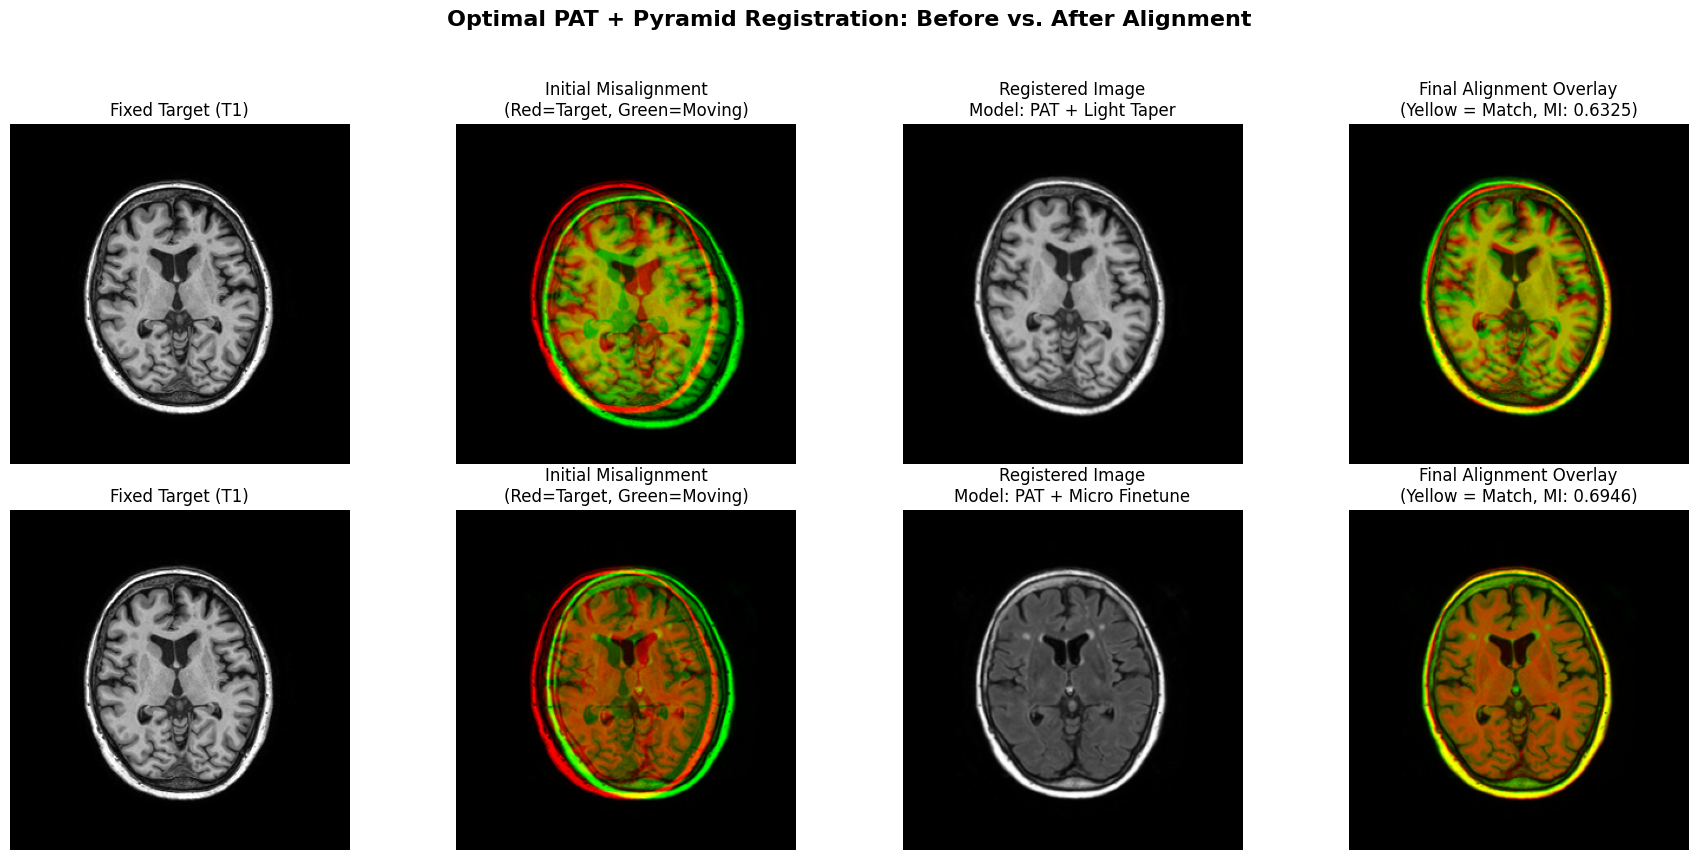

In [59]:
# 5. PLOT THE RESULTS
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Optimal PAT + Pyramid Registration: Before vs. After Alignment", fontsize=16, fontweight='bold')

# --- ROW 1: T1-T1 ---
axes[0, 0].imshow(image_f, cmap='gray')
axes[0, 0].set_title("Fixed Target (T1)")
axes[0, 0].axis('off')

axes[0, 1].imshow(create_overlay(image_f, image_d_t1))
axes[0, 1].set_title("Initial Misalignment\n(Red=Target, Green=Moving)")
axes[0, 1].axis('off')

axes[0, 2].imshow(reg_t1, cmap='gray')
axes[0, 2].set_title(f"Registered Image\nModel: {sched_t1['name']}")
axes[0, 2].axis('off')

axes[0, 3].imshow(create_overlay(image_f, reg_t1))
axes[0, 3].set_title(f"Final Alignment Overlay\n(Yellow = Match, MI: {sim_t1:.4f})")
axes[0, 3].axis('off')

# --- ROW 2: T1-T2 ---
axes[1, 0].imshow(image_f, cmap='gray')
axes[1, 0].set_title("Fixed Target (T1)")
axes[1, 0].axis('off')

axes[1, 1].imshow(create_overlay(image_f, image_d_t2))
axes[1, 1].set_title("Initial Misalignment\n(Red=Target, Green=Moving)")
axes[1, 1].axis('off')

axes[1, 2].imshow(reg_t2, cmap='gray')
axes[1, 2].set_title(f"Registered Image\nModel: {sched_t2['name']}")
axes[1, 2].axis('off')

axes[1, 3].imshow(create_overlay(image_f, reg_t2))
axes[1, 3].set_title(f"Final Alignment Overlay\n(Yellow = Match, MI: {sim_t2:.4f})")
axes[1, 3].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()